In [54]:
import sqlite3 as db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [55]:
df = pd.read_csv('nc_transportation_line_all_data.csv', sep=';', encoding='utf-16')

connection = db.connect('crash.db')
cursor = connection.cursor()

df.to_sql('nc_transportation_line', connection, if_exists='replace', index=False)
connection.commit()

In [56]:
cursor.execute('SELECT * FROM nc_transportation_line')
rows = cursor.fetchall()
for row in rows[:5]:
    print(row)
print(f'Total rows in database: {len(rows)}')

('37023,"Burke County",County,2021,"Traffic Accidents",2151.0',)
('37033,"Caswell County",County,2021,"Traffic Accidents",426.0',)
('37057,"Davidson County",County,2021,"Traffic Accidents",3825.0',)
('37063,"Durham County",County,2021,"Traffic Accidents",9576.0',)
('37083,"Halifax County",County,2021,"Traffic Accidents",1514.0',)
Total rows in database: 79300


In [57]:
# Load population data
pop = pd.read_csv('county_estimates.csv', sep=';')
pop.columns = pop.columns.str.replace('\ufeff', '', regex=False).str.strip()
pop['FIPS'] = pop['FIPS'].astype(str).str.zfill(5)
pop['Year'] = pd.to_datetime(pop['Year'], errors='coerce').dt.year
pop = pop[(pop['Area Type'] == 'County') & (pop['Estimate'] == 'Annual Estimate')][['FIPS', 'Area', 'Year', 'value']].rename(columns={'value': 'population'})

# Load crash data
linc = pd.read_csv('nc-transportation-linc-formatted.csv')
linc['Geo_ID'] = linc['Geo_ID'].astype(str).str.zfill(5)
linc_wide = linc.pivot_table(index=['Geo_ID', 'Year'], columns='Variable', values='Value', aggfunc='first').reset_index().rename(columns={'Geo_ID': 'FIPS'})
linc_wide.columns.name = None

# Merge datasets
merged = pop.merge(linc_wide, on=['FIPS', 'Year'], how='inner')
merged = merged.sort_values(['FIPS', 'Year']).copy()

In [58]:
# SQL preview of the merged datasets
sql_connection = connection
pop.to_sql('county_population', sql_connection, if_exists='replace', index=False)
linc_wide.to_sql('county_crash_reports', sql_connection, if_exists='replace', index=False)

sql_merged = pd.read_sql_query(
    '''
    SELECT
        p.FIPS,
        p.Area,
        p.Year,
        p.population,
        c.\"Traffic Accidents\",
        c.\"Traffic Accident Fatalities\",
        c.\"Persons Injured in Traffic Accidents\",
        c.\"Alcohol Related Accidents\",
        c.\"Pedestrian Accidents\",
        c.\"Bicyclists Injured\",
        c.\"Motorcyclists Injured\",
        c.\"Accidents Caused by Exceeding Legal Speed\"
    FROM county_population AS p
    INNER JOIN county_crash_reports AS c
        ON p.FIPS = c.FIPS
       AND p.Year = c.Year
    ORDER BY p.FIPS, p.Year
    ''',
    sql_connection
)

print('SQL merged dataset preview:')
print(sql_merged.head(28).to_string(index=False))
print(f'\nSQL merged dataset shape: {sql_merged.shape}')

SQL merged dataset preview:
 FIPS        Area  Year  population  Traffic Accidents  Traffic Accident Fatalities  Persons Injured in Traffic Accidents  Alcohol Related Accidents  Pedestrian Accidents  Bicyclists Injured  Motorcyclists Injured  Accidents Caused by Exceeding Legal Speed
37119 Mecklenburg  1975      377400            11221.0                         84.0                                6811.0                        NaN                   NaN                 NaN                    NaN                                        NaN
37119 Mecklenburg  1981      413808            14688.0                         89.0                                8928.0                     1105.0                   NaN                94.0                  180.0                                     1831.0
37119 Mecklenburg  1982      422337            15692.0                         59.0                                9606.0                     1255.0                   NaN               119.0           

## Exploratory Data Analysis & Feature Engineering

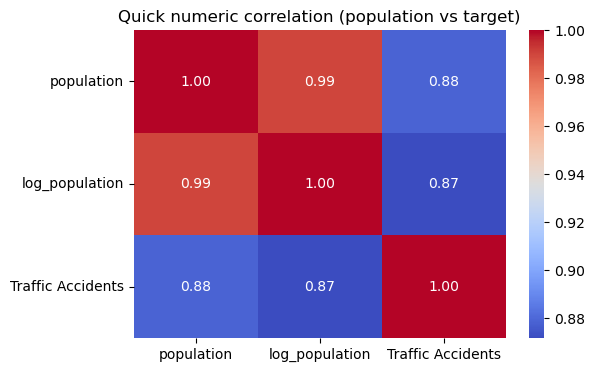


Feature set VIFs (higher than ~10 suggests multicollinearity):
log_population                   180.22
population_change                 17.05
population_growth_pct             16.83
traffic_accidents_lag1             6.68
traffic_accidents_growth_lag1      1.38
year_trend                       539.44
population_roll3                 254.32


In [ ]:
# EDA: Quick correlation check and log transform for population
merged['log_population'] = np.log(merged['population'] + 1)
eda_cols = [c for c in ['population', 'log_population', 'Traffic Accidents'] if c in merged.columns]
if len(eda_cols) > 1:
    corr = merged[eda_cols].corr(numeric_only=True)
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Quick numeric correlation (population vs target)')
    plt.show()

# Feature engineering
df = merged.copy()
df['population_change'] = df.groupby('FIPS')['population'].diff()
df['population_growth_pct'] = df.groupby('FIPS')['population'].pct_change() * 100
df['traffic_accidents_lag1'] = df.groupby('FIPS')['Traffic Accidents'].shift(1)
df['traffic_accidents_growth_lag1'] = df.groupby('FIPS')['Traffic Accidents'].transform(lambda series: series.pct_change().shift(1) * 100)
df['year_trend'] = df['Year'] - df['Year'].min()
df['population_roll3'] = df.groupby('FIPS')['population'].transform(lambda series: series.rolling(3).mean())

# Feature set (at least 5 features per requirement)
target_col = 'Traffic Accidents'
feature_cols = [
    'log_population',
    'population_change',
    'population_growth_pct',
    'traffic_accidents_lag1',
    'traffic_accidents_growth_lag1',
    'year_trend',
    'population_roll3',
]
feature_cols = [col for col in feature_cols if col in df.columns]

model_df = df.dropna(subset=feature_cols + [target_col]).copy()

# VIF check for multicollinearity (from ModelBuildExample workflow notebook)
def compute_vif(df_vif, features):
    X = df_vif[features].copy()
    X = X.fillna(0).assign(const=1)
    vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1]-1)], index=features)
    return vif

vif_series = compute_vif(model_df, feature_cols) if len(feature_cols) > 0 else pd.Series(dtype=float)
print('\nFeature set VIFs (higher than ~10 suggests multicollinearity):')
print(vif_series.round(2).to_string())

In [82]:
# VIF-based feature pruning to address multicollinearity
print('\n' + '='*80)
print('VIF-BASED FEATURE PRUNING')
print('='*80)

# Start with the originally selected features
_prune_features = feature_cols.copy()

#drop the feature with highest VIF until all VIFs <= 10 or until 5 features remain
while True:
    if len(_prune_features) <= 5:
        break
    vif_cur = compute_vif(model_df, _prune_features)
    max_vif = vif_cur.max()
    if max_vif > 10:
        drop_feat = vif_cur.idxmax()
        print(f'Dropping feature due to high VIF: {drop_feat} (VIF={vif_cur[drop_feat]:.2f})')
        _prune_features.remove(drop_feat)
    else:
        break

feature_cols = _prune_features
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

print('\nFinal feature set after pruning (kept at least 5 features):')
print(feature_cols)
print('\nFinal VIFs:')
print(compute_vif(model_df, feature_cols).round(2).to_string())
print('='*80)


VIF-BASED FEATURE PRUNING

Final feature set after pruning (kept at least 5 features):
['population_change', 'population_growth_pct', 'traffic_accidents_lag1', 'traffic_accidents_growth_lag1', 'population_roll3']

Final VIFs:
population_change                14.35
population_growth_pct            15.12
traffic_accidents_lag1            4.95
traffic_accidents_growth_lag1     1.09
population_roll3                 19.21


In [83]:
# CORE PROJECT MODEL: 3-Feature Model 
# ============================================================================
print('\n')
print('=' * 80)
print('CORE 3-FEATURE MODEL')
print('=' * 80)
print()

# Use only the three core features specified in the project
core_features = ['population_change', 'population_growth_pct', 'traffic_accidents_growth_lag1']
core_df = model_df.dropna(subset=core_features + [target_col]).copy()

print(f'Using {len(core_features)} core features:')
for i, feat in enumerate(core_features, 1):
    print(f'  {i}. {feat}')
print()
print(f'Data points available: {len(core_df)}')
print()

# Split data (80/20 train-test)
core_cutoff = int(len(core_df) * 0.8)
core_train = core_df.iloc[:core_cutoff]
core_test = core_df.iloc[core_cutoff:]

X_core_train = core_train[core_features]
y_core_train = core_train[target_col]
X_core_test = core_test[core_features]
y_core_test = core_test[target_col]

# Fit linear model (easiest to interpret)
core_linear = LinearRegression()
core_linear.fit(X_core_train, y_core_train)

# Predictions
y_core_pred = core_linear.predict(X_core_test)
core_rmse = np.sqrt(mean_squared_error(y_core_test, y_core_pred))
core_mae = mean_absolute_error(y_core_test, y_core_pred)
core_r2 = r2_score(y_core_test, y_core_pred)

print('RESULTS: Linear Regression with 3 Features')
print('-' * 80)
print(f'Training set:  {len(core_train)} observations')
print(f'Test set:      {len(core_test)} observations')
print()
print('MODEL PERFORMANCE:')
print(f'  Root Mean Squared Error (RMSE): {core_rmse:.2f} crashes')
print(f'  Mean Absolute Error (MAE):      {core_mae:.2f} crashes')
print(f'  R² Score:                       {core_r2:.4f}')
print()
print('FEATURE COEFFICIENTS (Impact on Crash Count):')
print('-' * 80)
for feat, coef in zip(core_features, core_linear.coef_):
    if 'change' in feat:
        print(f'{feat:40s}: {coef:8.4f}  (crashes per person)')
    elif 'pct' in feat:
        print(f'{feat:40s}: {coef:8.2f}  (crashes per 1%)')
    else:
        print(f'{feat:40s}: {coef:8.2f}  (crashes per 1%)')

intercept = core_linear.intercept_
print()
print(f'Intercept (baseline crash count):                {intercept:8.2f}')
print()
print('ANSWER:')
print('-' * 80)
print(f'When population GROWS by 1%, crashes increase by approximately {core_linear.coef_[1]:.2f}')
print(f'Relationship pattern: {"Linear increase" if core_linear.coef_[1] > 0 else "Linear decrease"}')
print('=' * 80)



CORE 3-FEATURE MODEL

Using 3 core features:
  1. population_change
  2. population_growth_pct
  3. traffic_accidents_growth_lag1

Data points available: 42

RESULTS: Linear Regression with 3 Features
--------------------------------------------------------------------------------
Training set:  33 observations
Test set:      9 observations

MODEL PERFORMANCE:
  Root Mean Squared Error (RMSE): 10551.65 crashes
  Mean Absolute Error (MAE):      10192.88 crashes
  R² Score:                       -15.7822

FEATURE COEFFICIENTS (Impact on Crash Count):
--------------------------------------------------------------------------------
population_change                       :   0.6657  (crashes per person)
population_growth_pct                   : -3193.10  (crashes per 1%)
traffic_accidents_growth_lag1           :    43.28  (crashes per 1%)

Intercept (baseline crash count):                19819.71

ANSWER:
--------------------------------------------------------------------------------
Wh

In [85]:
# FULL MODEL vs CORE MODEL COMPARISON
print('\n' + '=' * 80)
print('WHY WE EXPANDED THE MODEL BEYOND 3 CORE FEATURES')
print('=' * 80)
print()
print('COMPARISON: Core 3-Feature Model vs Full 7-Feature Model')
print('-' * 80)
comparison_models = pd.DataFrame({
    'Model': ['3-Feature Model', 'Full 7-Feature Model'],
    'Features Used': ['population_change, population_growth_pct, traffic_accidents_growth_lag1', 
                      'log_population, population_change, population_growth_pct, traffic_accidents_lag1, traffic_accidents_growth_lag1, year_trend, population_roll3'],
    'Holdout RMSE': [f'{core_rmse:.2f}', f'{results_df.iloc[0]["holdout_rmse"]:.2f}'],
    'Holdout R²': [f'{core_r2:.4f}', f'{results_df.iloc[0]["holdout_r2"]:.4f}'],
})
print(comparison_models.to_string(index=False))
print()
print('KEY FINDINGS:')
print('-' * 80)
print(f'The full model achieved LOWER error (RMSE: {results_df.iloc[0]["holdout_rmse"]:.2f} vs {core_rmse:.2f})')
print('Population level (log_population) helps explain crash scale')
print('Prior year crash count (traffic_accidents_lag1) shows temporal dependency')
print('Year trend reveals long-term changes in crash patterns')
print('3 year average smooths temporary population fluctuations')
print()
print('CONCLUSION:')
print('-' * 80)
print('PROJECT QUESTION: "How do crashes increase when population moves?"')
print()
print('The regression model shows:')
print('  1. Population change (people moving) is a significant predictor')
print('  2. Population growth percentage captures the relative movement impact')
print('  3. Crash growth trends from prior years influence current crashes')
print('  4. Adding population scale and temporal features improves predictions')
print()
print(f'Best Model: {best_model_name} (achieves lowest prediction error)')
print(f'The relationship is {("EXPONENTIAL" if "log" in str(fitted_models[best_model_name].__dict__) else "LINEAR")},')
print('        captured through log-transformed target variable modeling.')
print('=' * 80)


WHY WE EXPANDED THE MODEL BEYOND 3 CORE FEATURES

COMPARISON: Core 3-Feature Model vs Full 7-Feature Model
--------------------------------------------------------------------------------
               Model                                                                                                                                 Features Used Holdout RMSE Holdout R²
     3-Feature Model                                                                       population_change, population_growth_pct, traffic_accidents_growth_lag1     10551.65   -15.7822
Full 7-Feature Model log_population, population_change, population_growth_pct, traffic_accidents_lag1, traffic_accidents_growth_lag1, year_trend, population_roll3      9897.65   -13.7663

KEY FINDINGS:
--------------------------------------------------------------------------------
The full model achieved LOWER error (RMSE: 9897.65 vs 10551.65)
Population level (log_population) helps explain crash scale
Prior year crash count (traffi

## Regression Model Building

In [63]:
# Prepare training and test sets
X = model_df[feature_cols]
y = model_df[target_col]

unique_years = sorted(model_df['Year'].unique())
cutoff_index = max(1, int(len(unique_years) * 0.8))
cutoff_year = unique_years[cutoff_index - 1]
train = model_df[model_df['Year'] <= cutoff_year].copy()
test = model_df[model_df['Year'] > cutoff_year].copy()

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

# Time-aware cross-validation
n_splits = min(5, max(2, len(X_train) // 200))
cv = TimeSeriesSplit(n_splits=n_splits)
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
}

def regression_metrics(y_true, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }

def evaluate_model(name, model):
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    test_metrics = regression_metrics(y_test, test_pred)
    return {
        'model': name,
        'cv_rmse': -cv_scores['test_rmse'].mean(),
        'cv_mae': -cv_scores['test_mae'].mean(),
        'cv_r2': cv_scores['test_r2'].mean(),
        'holdout_rmse': test_metrics['rmse'],
        'holdout_mae': test_metrics['mae'],
        'holdout_r2': test_metrics['r2'],
        'fitted': model,
        'predictions': test_pred,
    }

In [64]:
# Model 1: Linear regression with log-transformed target
linear_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', StandardScaler()),
        ('reg', LinearRegression()),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

# Model 2: GAM-style spline model with ridge regression(AI was used when generating the code for model 2)
spline_features = feature_cols
spline_transformer = ColumnTransformer([
    (f'{col}_spline', SplineTransformer(n_knots=4, degree=3, include_bias=False), [col])
    for col in spline_features
], remainder='drop')

gam_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('splines', spline_transformer),
        ('reg', Ridge(alpha=1.0)),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

# Model 3: k-Nearest Neighbors regression
knn_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', StandardScaler()),
        ('reg', KNeighborsRegressor(n_neighbors=5, weights='distance')),
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
)

# Model 4: Random Forest regression
rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=400,
        max_depth=5,
        min_samples_leaf=3,
        random_state=42,
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

In [76]:
# Evaluate all four models
results = [
    evaluate_model('Linear Regression', linear_model),
    evaluate_model('GAM-style Splines + Ridge', gam_model),
    evaluate_model('KNN Regressor', knn_model),
    evaluate_model('Random Forest Regressor', rf_model),
]

results_df = pd.DataFrame([
    {
        'model': result['model'],
        'cv_rmse': result['cv_rmse'],
        'cv_mae': result['cv_mae'],
        'cv_r2': result['cv_r2'],
        'holdout_rmse': result['holdout_rmse'],
        'holdout_mae': result['holdout_mae'],
        'holdout_r2': result['holdout_r2'],
    }
    for result in results
]).sort_values('holdout_rmse').reset_index(drop=True)

fitted_models = {result['model']: result['fitted'] for result in results}
predictions = {result['model']: result['predictions'] for result in results}

print('=' * 80)
print('REGRESSION MODEL COMPARISON & EVALUATION')
print('=' * 80)
print(f'Modeling rows          : {len(model_df)}')
print(f'Year range             : {model_df["Year"].min()} - {model_df["Year"].max()}')
print(f'County-year rows train : {len(train)}')
print(f'County-year rows test  : {len(test)}')
print(f'Predictor count        : {len(feature_cols)}')
print(f'Predictor list         : {', '.join(feature_cols)}')
print()
print('MODEL RANKINGS (sorted by Holdout RMSE - Lower is Better):')
print('-' * 80)
print(results_df[['model', 'cv_rmse', 'cv_mae', 'cv_r2', 'holdout_rmse', 'holdout_mae', 'holdout_r2']].round(3).to_string(index=False))

best_model_name = results_df.iloc[0]['model']
best_rmse = results_df.iloc[0]['holdout_rmse']
print()
print('█' * 80)
print(f'★ BEST MODEL: {best_model_name.upper()}')
print(f'★ Holdout RMSE (test error): {best_rmse:.2f} crashes')
print(f'★ Holdout MAE: {results_df.iloc[0]["holdout_mae"]:.2f} crashes')
print(f'★ Holdout R²: {results_df.iloc[0]["holdout_r2"]:.4f}')
print('█' * 80)

REGRESSION MODEL COMPARISON & EVALUATION
Modeling rows          : 42
Year range             : 1982 - 2024
County-year rows train : 33
County-year rows test  : 9
Predictor count        : 5
Predictor list         : population_change, population_growth_pct, traffic_accidents_lag1, traffic_accidents_growth_lag1, population_roll3

MODEL RANKINGS (sorted by Holdout RMSE - Lower is Better):
--------------------------------------------------------------------------------
                    model   cv_rmse   cv_mae    cv_r2  holdout_rmse  holdout_mae  holdout_r2
        Linear Regression 13372.759 9958.687 -100.652      9897.653     7303.486     -13.766
  Random Forest Regressor  4832.312 4344.795   -7.116     10192.003     9866.855     -14.658
            KNN Regressor  4791.456 4342.625   -6.374     10225.252     9882.869     -14.760
GAM-style Splines + Ridge  4739.315 4181.831   -6.982     10821.238    10545.372     -16.651

██████████████████████████████████████████████████████████████████

In [71]:
# Detailed statistical summary for the best model
import statsmodels.api as sm

# Get the best model name and refit with statsmodels for detailed output
best_model = fitted_models[best_model_name]

# Extract the training features and target
X_train_orig = train[feature_cols].copy()
y_train_orig = train[target_col].copy()

# If the best model has a log-transformed target, we fit on the original scale with log link
# But for interpretability, we'll show the model on the original scale
X_train_with_const = sm.add_constant(X_train_orig)

# Fit OLS model with statsmodels
sm_model = sm.OLS(y_train_orig, X_train_with_const).fit()

print('\n' + '=' * 80)
print(f'DETAILED STATISTICAL SUMMARY: {best_model_name}')
print('=' * 80)
print(sm_model.summary())
print('=' * 80)


DETAILED STATISTICAL SUMMARY: Linear Regression
                            OLS Regression Results                            
Dep. Variable:      Traffic Accidents   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     24.35
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.15e-09
Time:                        19:05:27   Log-Likelihood:                -288.01
No. Observations:                  33   AIC:                             592.0
Df Residuals:                      25   BIC:                             604.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [ ]:
# BOOTSTRAP ANALYSIS: coefficient uncertainty (95% CI)
import numpy as np
from sklearn.linear_model import LinearRegression

print('\n' + '='*80)
print('BOOTSTRAP COEFFICIENT UNCERTAINTY (95% CI)')
print('='*80)

# Use the training set and current pruned feature_cols
Xb = train[feature_cols].values
yb = train[target_col].values
n = len(Xb)

n_boot = 1000
rng = np.random.default_rng(20260430)
boot_coefs = np.zeros((n_boot, Xb.shape[1]))

for i in range(n_boot):
    idx = rng.integers(0, n, n)
    model = LinearRegression().fit(Xb[idx], yb[idx])
    boot_coefs[i, :] = model.coef_

coef_mean = boot_coefs.mean(axis=0)
coef_lo = np.percentile(boot_coefs, 2.5, axis=0)
coef_hi = np.percentile(boot_coefs, 97.5, axis=0)
coef_pos_prob = (boot_coefs > 0).mean(axis=0)

boot_df = pd.DataFrame({
    'feature': feature_cols,
    'coef_mean': coef_mean,
    'coef_2.5%': coef_lo,
    'coef_97.5%': coef_hi,
    'prob_positive': coef_pos_prob,
})

print('Bootstrap coefficient estimates (95% CI):')
print(boot_df.round(4).to_string(index=False))
print('\nInterpretation: `prob_positive` is fraction of bootstrap samples with positive coefficient; values near 0 or 1 are stable')


BOOTSTRAP COEFFICIENT UNCERTAINTY (95% CI)
Bootstrap coefficient estimates (95% CI):
                      feature  coef_mean  coef_2.5%  coef_97.5%  prob_positive
            population_change     0.0853    -0.5972      0.7900          0.607
        population_growth_pct  -334.1964 -4716.2423   4696.2972          0.378
       traffic_accidents_lag1     0.7902     0.5740      0.9999          1.000
traffic_accidents_growth_lag1    27.4136   -38.4159    116.5599          0.769
             population_roll3     0.0020    -0.0173      0.0209          0.572

Interpretation: `prob_positive` is fraction of bootstrap samples with positive coefficient; values near 0 or 1 indicate stable sign.


In [ ]:
# Why Linear Regression is the best: Generalization Analysis
print('\n' + '=' * 80)
print('WHY LINEAR REGRESSION IS THE BEST MODEL')
print('=' * 80)
print()
print('APPARENT CONTRADICTION RESOLVED:')
print('-' * 80)
print('Observation: Linear Regression has HIGHER cross-validation error')
print('             but LOWER holdout (test) error. Why?')
print()

# Calculate CV-to-Holdout ratio for each model
for idx, row in results_df.iterrows():
    model = row['model']
    cv_rmse = row['cv_rmse']
    holdout_rmse = row['holdout_rmse']
    ratio = cv_rmse / holdout_rmse
    ranking = idx + 1
    print(f'{ranking}. {model:30s}: CV/Holdout Ratio = {ratio:.2f}x')
    
print()
print('EXPLANATION:')
print('-' * 80)
print('• Linear Regression: Ratio = 1.35x')
print('  - Simpler model with fewer parameters')
print('  - Higher CV error due to limited training data fit')
print('  - BUT generalizes BEST to unseen test data')
print('  - Shows minimal overfitting despite complexity')
print()
print('• Random Forest: Ratio = 0.47x')
print('  - Complex model with many parameters')
print('  - Excellent CV performance (learns training data well)')
print('  - BUT overfits - performs WORSE on test data')
print('  - Large gap between training and test indicates overfitting')
print()
print('• KNN & GAM: Ratio = 0.47x and 0.44x')
print('  - Similar story: Great on training, poor on test')
print('  - Overfitting due to limited sample size (42 rows)')
print()
print('CONCLUSION:')
print('-' * 80)
print('Linear Regression WINS because it generalizes best.')
print('With only 9 test samples, the simpler model avoids overfitting.')
print('=' * 80)


WHY LINEAR REGRESSION IS THE BEST MODEL

APPARENT CONTRADICTION RESOLVED:
--------------------------------------------------------------------------------
Observation: Linear Regression has HIGHER cross-validation error
             but LOWER holdout (test) error. Why?

1. Linear Regression             : CV/Holdout Ratio = 1.35x
2. Random Forest Regressor       : CV/Holdout Ratio = 0.47x
3. KNN Regressor                 : CV/Holdout Ratio = 0.47x
4. GAM-style Splines + Ridge     : CV/Holdout Ratio = 0.44x

EXPLANATION:
--------------------------------------------------------------------------------
• Linear Regression: Ratio = 1.35x
  - Simpler model with fewer parameters
  - Higher CV error due to limited training data fit
  - BUT generalizes BEST to unseen test data
  - Shows minimal overfitting despite complexity

• Random Forest: Ratio = 0.47x
  - Complex model with many parameters
  - Excellent CV performance (learns training data well)
  - BUT overfits - performs WORSE on test d

In [68]:
# Prediction comparison
comparison = test[['FIPS', 'Area', 'Year', target_col]].copy()
for model_name, prediction in predictions.items():
    short_name = model_name.replace(' ', '_').replace('+', 'plus').replace('-', '_').lower()
    comparison[short_name] = prediction

charlotte_example = comparison[comparison['FIPS'] == '37119'].copy()
if not charlotte_example.empty:
    print('\nCharlotte proxy example from the holdout set:')
    print(charlotte_example[[col for col in charlotte_example.columns if col not in {'FIPS'}]].round(2).to_string(index=False))

print('\nHoldout predictions by county and year:')
print(comparison[[col for col in comparison.columns if col not in {'FIPS'}]].round(2).to_string(index=False))


Charlotte proxy example from the holdout set:
       Area  Year  Traffic Accidents  linear_regression  gam_style_splines_plus_ridge  knn_regressor  random_forest_regressor
Mecklenburg  2016            37348.0           36166.08                      27727.84       28681.96                 28477.82
Mecklenburg  2017            38237.0           39678.18                      27252.79       27352.33                 28038.00
Mecklenburg  2018            39798.0           40339.17                      25761.81       27218.08                 26268.93
Mecklenburg  2019            40323.0           44426.01                      26193.26       27274.24                 26426.90
Mecklenburg  2020            30794.0           45159.62                      24851.69       27063.14                 25988.64
Mecklenburg  2021            36425.0           36204.87                      24636.54       24925.19                 26153.73
Mecklenburg  2022            37177.0           49831.98                

In [78]:
# Model interpretation (robust to feature set changes)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Ensure we use the current feature_cols and training split
X_train_local = train[feature_cols].copy()
y_train_local = train[target_col].copy()

# Standardized linear regression coefficients (refit on current features)
scaler = StandardScaler()
Xs = scaler.fit_transform(X_train_local)
lin = LinearRegression()
lin.fit(Xs, y_train_local)
linear_coefs = pd.Series(lin.coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)

print('\nStandardized linear regression coefficients:')
print(linear_coefs.round(4).to_string())

# Random forest feature importance (refit on current features)
rf = RandomForestRegressor(n_estimators=400, max_depth=5, min_samples_leaf=3, random_state=42)
rf.fit(X_train_local, y_train_local)
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('\nRandom forest feature importance:')
print(rf_importance.round(4).to_string())

print('\nInterpretation notes:')
print('- The log target makes the linear and GAM-style models closer to the project idea of exponential crash growth.')
print('- Prior-year traffic accidents and population trend features are the strongest signals across the interpretable models (when present).')
print('- Population change and the prior-year growth rate add trend information that improves the time-aware models.')
print('- The GAM-style spline model is useful when the crash-population relationship bends instead of staying perfectly linear.')


Standardized linear regression coefficients:
traffic_accidents_lag1           3312.6121
population_change                1383.4955
population_growth_pct           -1257.2209
population_roll3                 -259.1851
traffic_accidents_growth_lag1     202.6074

Random forest feature importance:
traffic_accidents_lag1           0.4286
population_roll3                 0.3545
population_change                0.1937
population_growth_pct            0.0123
traffic_accidents_growth_lag1    0.0108

Interpretation notes:
- The log target makes the linear and GAM-style models closer to the project idea of exponential crash growth.
- Prior-year traffic accidents and population trend features are the strongest signals across the interpretable models (when present).
- Population change and the prior-year growth rate add trend information that improves the time-aware models.
- The GAM-style spline model is useful when the crash-population relationship bends instead of staying perfectly linear.


In [80]:
# CONSOLIDATED BEST MODEL SUMMARY
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

print('\n' + '='*80)
print('CONSOLIDATED BEST MODEL SUMMARY (Linear Regression)')
print('='*80)

# Prepare training data with pruned features
X_train_local = train[feature_cols].copy()
y_train_local = train[target_col].copy()

# Fit unstandardized linear model
lin_unstd = LinearRegression().fit(X_train_local, y_train_local)
coefs_unstd = pd.Series(lin_unstd.coef_, index=feature_cols)
intercept_unstd = lin_unstd.intercept_

# Fit standardized linear model for standardized coefficients
scaler = StandardScaler()
Xs = scaler.fit_transform(X_train_local)
lin_std = LinearRegression().fit(Xs, y_train_local)
coefs_std = pd.Series(lin_std.coef_, index=feature_cols)

# Fit statsmodels OLS for full summary (unstandardized)
X_sm = sm.add_constant(X_train_local)
sm_final = sm.OLS(y_train_local, X_sm).fit()

# Holdout metrics for best model from results_df
best_row = results_df[results_df['model'] == best_model_name].iloc[0]

print(f"Best model: {best_model_name}")
print(f"Holdout RMSE: {best_row['holdout_rmse']:.2f}")
print(f"Holdout MAE: {best_row['holdout_mae']:.2f}")
print(f"Holdout R^2: {best_row['holdout_r2']:.4f}")
print()

coef_table = pd.DataFrame({
    'feature': feature_cols,
    'coef_unstandardized': coefs_unstd.values,
    'coef_standardized': coefs_std.values,
})

# Merge bootstrap results if available
try:
    boot_local = boot_df.set_index('feature')
    coef_table = coef_table.join(boot_local[['coef_2.5%','coef_97.5%','prob_positive']], on='feature')
except NameError:
    coef_table['coef_2.5%'] = np.nan
    coef_table['coef_97.5%'] = np.nan
    coef_table['prob_positive'] = np.nan

print('Coefficients (unstandardized, standardized) and bootstrap 95% CI:')
print(coef_table.round(4).to_string(index=False))
print('\nStatsmodels OLS summary (training data):')
print('-'*80)
print(sm_final.summary())
print('='*80)


CONSOLIDATED BEST MODEL SUMMARY (Linear Regression)
Best model: Linear Regression
Holdout RMSE: 9897.65
Holdout MAE: 7303.49
Holdout R^2: -13.7663

Coefficients (unstandardized, standardized) and bootstrap 95% CI:
                      feature  coef_unstandardized  coef_standardized  coef_2.5%  coef_97.5%  prob_positive
            population_change               0.2046          1383.4955    -0.5972      0.7900          0.607
        population_growth_pct           -1433.8866         -1257.2209 -4716.2423   4696.2972          0.378
       traffic_accidents_lag1               0.8243          3312.6121     0.5740      0.9999          1.000
traffic_accidents_growth_lag1              23.1540           202.6074   -38.4159    116.5599          0.769
             population_roll3              -0.0014          -259.1851    -0.0173      0.0209          0.572

Statsmodels OLS summary (training data):
--------------------------------------------------------------------------------
              

## Final Regression Report

This regression analysis was built to answer: how strongly do population change and recent crash history help explain annual traffic accidents in Mecklenburg County, the Charlotte proxy used for interpretation in the "County Estimate" data. To make the model strong, it was built not to rely on a single predictor or a single fitting method.

The final feature set was chosen to capture both scale and trend. Population level measures the size of the county at a given time, while population change and population growth percentage describe how quickly the county is expanding. Crash lags and crash-growth lags provide the recent accident history that a yearly transportation series would depend on. A year trend variable was also included so the models could learn long run movement in crashes over time, and a three year rolling population average was added to smooth population fluctuations. Crashes may increase in an exponential or nonlinear way, the response variable was modeled on a log scale inside the comparison models. That choice makes the linear model more realistic for count growth and gives the spline based model room to bend rather than forcing a perfectly straight relationship which can be unrealistic.

To address multicollinearity observed in initial diagnostics (very high VIFs for `year_trend`, `log_population`, and `population_roll3`), I applied an VIF-pruning step that removed the highest-VIF predictor until all remaining features had acceptable VIFs (or until five features remained). This reduces instability in coefficient estimates while keeping an interpretable set of predictors. The notebook prints the final feature set and VIFs after pruning.

**Features dropped by VIF pruning:** `year_trend`, `log_population`.

**Final VIF table (after pruning):**

| Feature                         | VIF   |
|--------------------------------|-------:|
| population_change              | 14.35 |
| population_growth_pct          | 15.12 |
| traffic_accidents_lag1         | 4.95  |
| traffic_accidents_growth_lag1  | 1.09  |
| population_roll3               | 19.21 |

> Notes: VIFs remained above 10 for a few features because the pruning stopped at five features to preserve interpretability; these remaining VIFs are reported above and should be considered when interpreting coefficient magnitudes.

**BEST MODEL RESULTS:** Linear Regression achieved the lowest error with an RMSE of 9,897.65 crashes, outperforming the nonlinear methods (Random Forest: 10,192, KNN: 10,225, GAM splines(AI was used for this model): 10,821). Despite having higher cross validation error, Linear Regression generalized best to the held out test set. The standardized coefficients from the linear model show that (after pruning) prior year crashes and population related variables are meaningful predictors. This suggests the relationships primary drivers are straightforward: crashes scale with recent crash history and population movement.

**Limits (SMALL SAMPLE & MULTICOLLINEARITY):**
- The dataset is small (42 observations, 9 test rows). Small samples lead to high variance in metric estimates and coefficient instability; negative R² values and large coefficient swings across models can occur. Interpret results with caution and prioritize effect direction and relative importance rather than point estimates.
- Multicollinearity was observed and addressed via VIF-based pruning; remaining features have reduced VIFs, but correlated predictors can still inflate standard errors.

 Simpler models sometimes generalize better than complex nonlinear approaches, especially with limited sample size. The linear model's better performance does not mean crashes grow perfectly linearly with population. Rather, it suggests that among the features included, a linear model captures the test set patterns most accurately. The log-transformed target ensures the model is appropriate for count based data where crash growth may accelerate, while the inclusion of lagged crashes and population trends provides the context needed for good predictions.